In [1]:

import os
os.environ['MEMORY_LIMIT'] = '24GB'
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import gridspec
from os.path import exists, join
from io import StringIO  
from datetime import timedelta
import math

ALGORITHMS = {
    'structural': 'Structural filter',
    'sed': 'SED',
    'lblint': 'Label intersection',
    'bib': 'Binary branch',
    'sedstruct': 'SED-struct',
}

datasets = [ds for ds in os.listdir('datasets') if os.path.isdir(join('datasets', ds))]


In [2]:
real_datasets = [ds for ds in datasets if 'fanout' not in ds and 'labels-' not in ds]
label_datasets = [ds for ds in datasets if 'labels-' in ds]
fanout_datasets = [ds for ds in datasets if 'fanout' in ds]
fanout_datasets = sorted([ds for ds in datasets if 'fanout' in ds], 
             key=lambda x: {'high': 0, 'medium': 1, 'small': 2, 'low': 3, 'verylow': 4}.get(x.split('-')[0], 5))

selectivities_datasets = [('dblp', [2, 3, 5, 10]), ('sentiment', [2, 3, 5, 10])]

In [3]:
fanout_datasets

['high-fanout',
 'medium-fanout',
 'small-fanout',
 'low-fanout',
 'verylow-fanout']

In [4]:
algorithm_order = [ALGORITHMS['bib'], ALGORITHMS['lblint'], ALGORITHMS['structural'], ALGORITHMS['sed'], ALGORITHMS['sedstruct']]

def read_query_times(dataset: str) -> pd.DataFrame:
    data = []
    file_path = join('datasets', dataset, 'query_times.csv')
    if not exists(file_path):
        return pd.DataFrame()
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    current_algorithm = None
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        # Check if this is an algorithm name (doesn't contain ':')
        if ':' not in line:
            current_algorithm = line
        # Check if this is a time line
        elif line.startswith('time:'):
            time_str = line.replace('time:', '').replace('ms', '').strip()
            try:
                filter_time = float(time_str)
                alg_name = ALGORITHMS.get(current_algorithm.lower(), None)
                if alg_name is not None:
                  data.append({
                      'algorithm': alg_name,
                      'filter_time_ms': filter_time
                  })
            except ValueError:
                pass
    
    
    
    if data:
        return pd.DataFrame(data)
    else:
        return pd.DataFrame()

In [5]:
real_datasets
hatch_patterns = {
    ALGORITHMS['lblint']: '--',
    ALGORITHMS['bib']: 'oo',
    ALGORITHMS['structural']: '\\\\\\',
    ALGORITHMS['sed']: 'xx',
    ALGORITHMS['sedstruct']: '**'
}

# Filtering times only plot

/tmp/ipykernel_17762/4148216253.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):


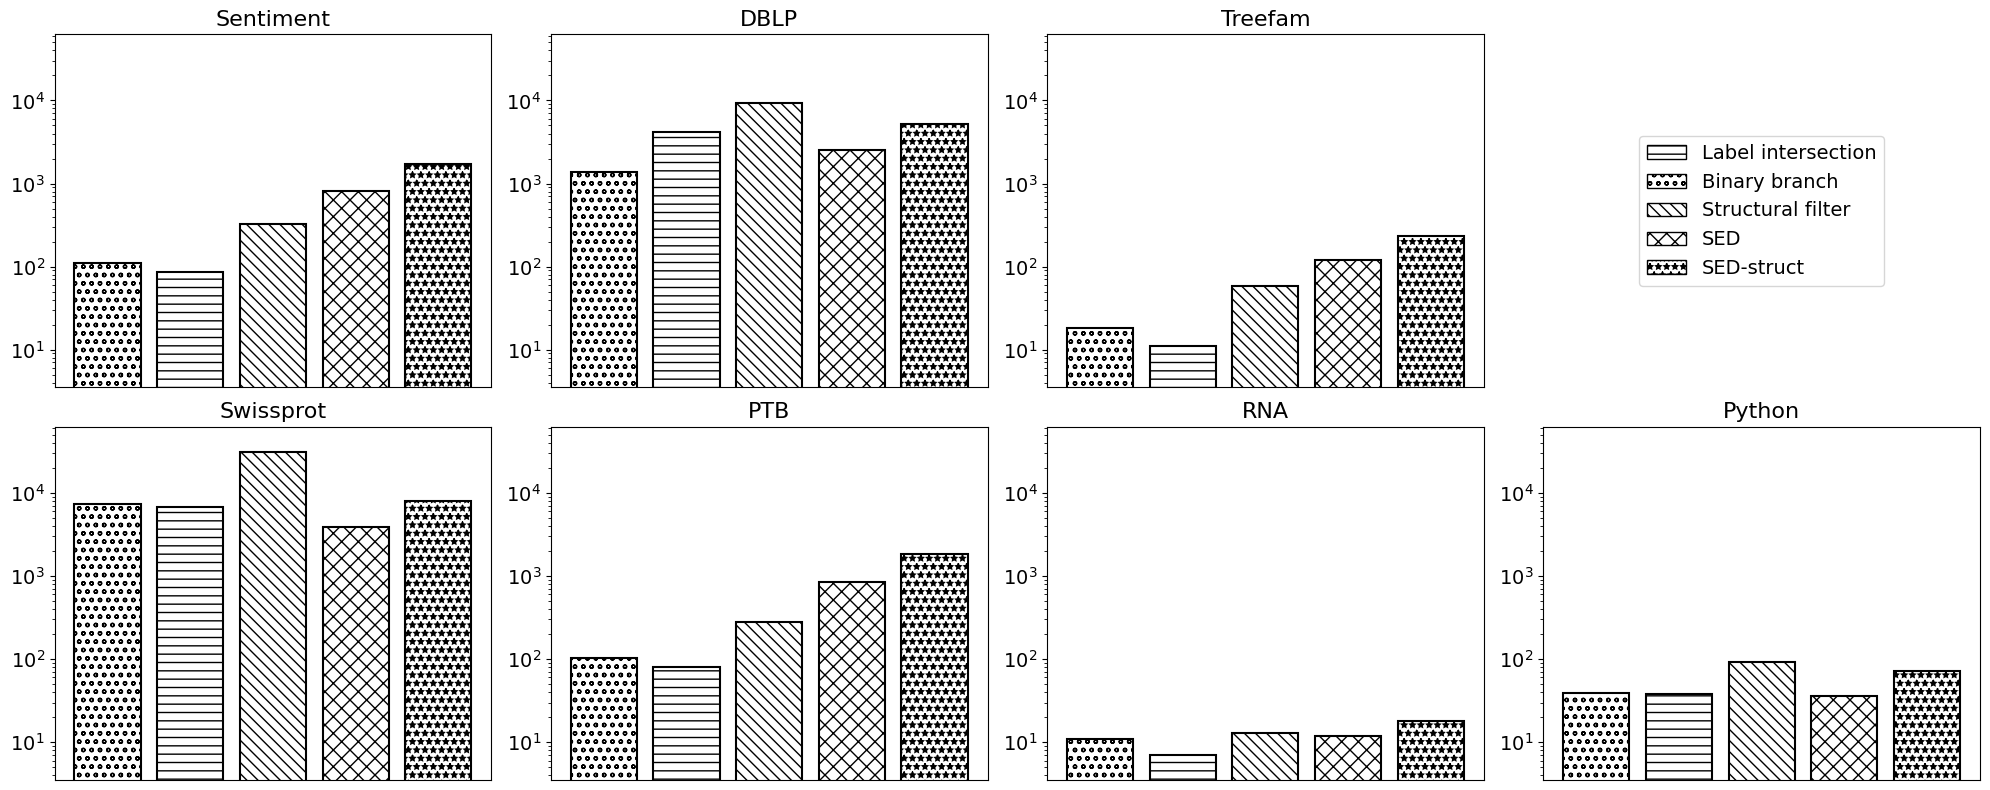

In [ ]:
filter_df = pd.DataFrame()
for real_ds in real_datasets:
  filter_df_ds = read_query_times(real_ds)
  filter_df_ds['dataset'] = real_ds.capitalize() if real_ds not in ('dblp', 'rna', 'ptb') else real_ds.upper()
  filter_df = pd.concat([filter_df, filter_df_ds], ignore_index=True)
filter_df['algorithm'] = pd.Categorical(filter_df['algorithm'], categories=algorithm_order, ordered=True)
filter_df = filter_df.sort_values('algorithm')



# Calculate global min and max for normalization
global_min = filter_df['filter_time_ms'].min()
global_max = filter_df['filter_time_ms'].max()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for idx, dataset in enumerate(real_datasets):
  dataset_data = filter_df[filter_df['dataset'] == (dataset.capitalize() if dataset not in ('dblp', 'rna', 'ptb') else dataset.upper())]
  ax = axes[idx + (1 if idx >= 3 else 0)]
  
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):
    bar = ax.bar(i, group['filter_time_ms'].values[0], color='white', edgecolor='black', linewidth=1.5, hatch=hatch_patterns[algorithm])
  
  ax.set_xticks([])
  ax.tick_params(axis='y', labelsize=14)
  ax.set_title(dataset.capitalize() if dataset not in ('dblp', 'rna', 'ptb') else dataset.upper(), fontsize=16)
  ax.set_yscale('log')
  ax.set_ylim(global_min * 0.5, global_max * 2)

# Use the last subplot for the legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='white', edgecolor='black', hatch=hatch, label=alg) 
                   for alg, hatch in hatch_patterns.items()]

axes[3].axis('off')
axes[3].legend(handles=legend_elements, loc='center', fontsize=14, frameon=True)


plt.tight_layout()
plt.savefig('filter_query_times_real_datasets.pdf', format='pdf')

plt.show()

# Total time plotting

In [8]:
real_ds = 'sentiment'
verify_file = join('datasets', real_ds, 'verified-all.csv')
verify_df = pd.read_csv(verify_file, dtype={'query_id': 'int32', 'candidate_id': 'int32', 'verification_time_micro': 'float', 'final_ted': 'float', 'passed': 'bool'}, skipfooter=1, engine='python')


for algorithm in ALGORITHMS.keys():
  alg = algorithm.capitalize() if algorithm != 'sedstruct' else 'SEDStruct'
  candidates_file = join('datasets', real_ds, f'{alg}_candidates.csv')
  if exists(candidates_file):
    candidates_ds = pd.read_csv(candidates_file, header=None, names=['query_id', 'candidate_id'])
    candidates_ds['algorithm'] = ALGORITHMS[algorithm]
    # merge verify on QT and CT 
    merged = pd.merge(candidates_ds, verify_df, on=['query_id', 'candidate_id'], how='inner')
    print(f'{algorithm}', len(merged), len(merged[merged['passed'] == 1]))
    # summarize verification times in microseconds and convert to milliseconds
    total_verify_time_ms = merged['verification_time_micro'].sum() / 1000.0
    # compute precision of the algorithm - the fraction of candidates that were verified as true positives
    precision = 100 * (len(merged[merged['passed'] == 1]) / len(merged))

structural 451398 10652
sed 134658 10652
lblint 502728 10652
bib 964500 10652
sedstruct 29109 10652


In [9]:
real_ds = 'sentiment'
sed_candidates_file = join('datasets', real_ds, f'Sed_candidates.csv')
sed_candidates_ds = pd.read_csv(sed_candidates_file, header=None, names=['query_id', 'candidate_id'])

sed_row = sed_candidates_ds[(sed_candidates_ds['query_id'] == 0) & (sed_candidates_ds['candidate_id'] == 1524)]
display(sed_row, len(sed_row))

structural_candidates_file = join('datasets', real_ds, f'Structural_candidates.csv')
structural_candidates_ds = pd.read_csv(structural_candidates_file, header=None, names=['query_id', 'candidate_id'])


merged = pd.merge(structural_candidates_ds, sed_candidates_ds, on=['query_id', 'candidate_id'], how='left', indicator=True)

display(merged, len(merged))  

mvf = pd.merge(merged, verify_df, on=['query_id', 'candidate_id'], how='inner')

display(mvf[mvf['passed'] == True])


,query_id,candidate_id
66,0,1524


1

,query_id,candidate_id,_merge
0,0,839,both
1,0,863,left_only
2,0,867,left_only
3,0,884,both
4,0,908,both
...,...,...,...
451393,99,7649,left_only
451394,99,7656,left_only
451395,99,7662,left_only
451396,99,7733,left_only


451398

,query_id,candidate_id,_merge,verification_time_micro,final_ted,passed
0,0,839,both,168.0,30.0,True
6,0,1081,both,190.0,30.0,True
9,0,1096,both,193.0,30.0,True
15,0,1126,both,217.0,30.0,True
41,0,1265,both,246.0,30.0,True
...,...,...,...,...,...,...
449948,99,5330,both,486.0,29.0,True
449965,99,5347,both,347.0,30.0,True
449972,99,5354,both,468.0,0.0,True
449979,99,5361,both,461.0,29.0,True


In [9]:
# Initialize new columns in filter_df if they don't exist
if 'verify_time_ms' not in filter_df.columns:
    filter_df['verify_time_ms'] = 0.0
if 'precision' not in filter_df.columns:
    filter_df['precision'] = 0.0
    
results_list = []

for real_ds in real_datasets:
  verify_file = join('datasets', real_ds, 'verified-all.csv')
  verify_df = pd.read_csv(verify_file, dtype={'query_id': 'int32', 'candidate_id': 'int32', 'verification_time_micro': 'float', 'final_ted': 'float', 'passed': 'bool'}, on_bad_lines='skip', engine='pyarrow')
  
  # Set multi-index for faster lookups - do this once per dataset
  verify_df = verify_df.set_index(['query_id', 'candidate_id'])
  
  for algorithm in ALGORITHMS.keys():
    alg = algorithm.capitalize() if algorithm != 'sedstruct' else 'SEDStruct'
    candidates_file = join('datasets', real_ds, f'{alg}_candidates.csv')
    if exists(candidates_file):
      candidates_ds = pd.read_csv(candidates_file, header=None, dtype={'query_id': 'int32', 'candidate_id': 'int32'}, engine='pyarrow', names=['query_id', 'candidate_id'])
      
      # Set index on candidates and use join instead of merge (much faster)
      candidates_ds = candidates_ds.set_index(['query_id', 'candidate_id'])
      merged = candidates_ds.join(verify_df, how='inner')
      
      if not merged.empty:
        # Vectorized calculations
        passed_count = merged['passed'].sum()
        total_verify_time_ms = merged['verification_time_micro'].sum() / 1000.0
        precision = (passed_count / len(merged))
        
        # Format dataset name for the final lookup
        ds_display = real_ds.upper() if real_ds in ('dblp', 'rna', 'ptb') else real_ds.capitalize()
        
        # Store results for a single bulk update
        results_list.append({
            'dataset': ds_display,
            'algorithm': ALGORITHMS[algorithm],
            'verify_time_ms': total_verify_time_ms,
            'precision': precision
        })
          
        print(f'{algorithm} {passed_count}')
      
# One-shot update
results_df = pd.DataFrame(results_list)
filter_df = filter_df.set_index(['dataset', 'algorithm'])
filter_df.update(results_df.set_index(['dataset', 'algorithm']))
filter_df = filter_df.reset_index()


structural 10652
sed 10652
lblint 10652
bib 10652
sedstruct 10652
structural 134598
sed 134598
lblint 134598
bib 134598
sedstruct 134598
structural 6182
sed 6182
lblint 6182
bib 6182
sedstruct 6182
structural 1301
sed 1301
lblint 1301
bib 1301
sedstruct 1301
structural 6841
sed 6841
lblint 6841
bib 6841
sedstruct 6841
structural 24491
sed 24491
lblint 24491
bib 24491
sedstruct 24491
structural 80506
sed 80506
lblint 80506
bib 117215
sedstruct 80506


/tmp/ipykernel_17762/3210996115.py:48: PerformanceWarning: indexing past lexsort depth may impact performance.
  filter_df.update(results_df.set_index(['dataset', 'algorithm']))
/tmp/ipykernel_17762/3210996115.py:48: PerformanceWarning: indexing past lexsort depth may impact performance.
  filter_df.update(results_df.set_index(['dataset', 'algorithm']))


In [10]:
filter_df['precision_percent'] = filter_df['precision'] * 100
filter_df['total_time_ms'] = filter_df['verify_time_ms'] + filter_df['filter_time_ms']

In [11]:
# filter_df['precision'] = filter_df['precision'] * 100.0
filter_df

,dataset,algorithm,filter_time_ms,verify_time_ms,precision,precision_percent,total_time_ms
0,Swissprot,Binary branch,7261.0,238314.133,0.000067,0.006689,245575.133
1,Python,Binary branch,39.0,9351.808,0.033857,3.385748,9390.808
2,Sentiment,Binary branch,110.0,327983.557,0.011044,1.104406,328093.557
3,RNA,Binary branch,11.0,1029.451,0.014594,1.459367,1040.451
4,PTB,Binary branch,103.0,518164.174,0.017852,1.785230,518267.174
5,Treefam,Binary branch,18.0,151644.268,0.012372,1.237165,151662.268
6,DBLP,Binary branch,1366.0,397069.082,0.009639,0.963923,398435.082
7,Python,Label intersection,38.0,4078.172,0.726333,72.633279,4116.172
8,RNA,Label intersection,7.0,457.063,0.473393,47.339325,464.063
9,PTB,Label intersection,81.0,354294.921,0.028166,2.816617,354375.921


/tmp/ipykernel_17762/2053517056.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):


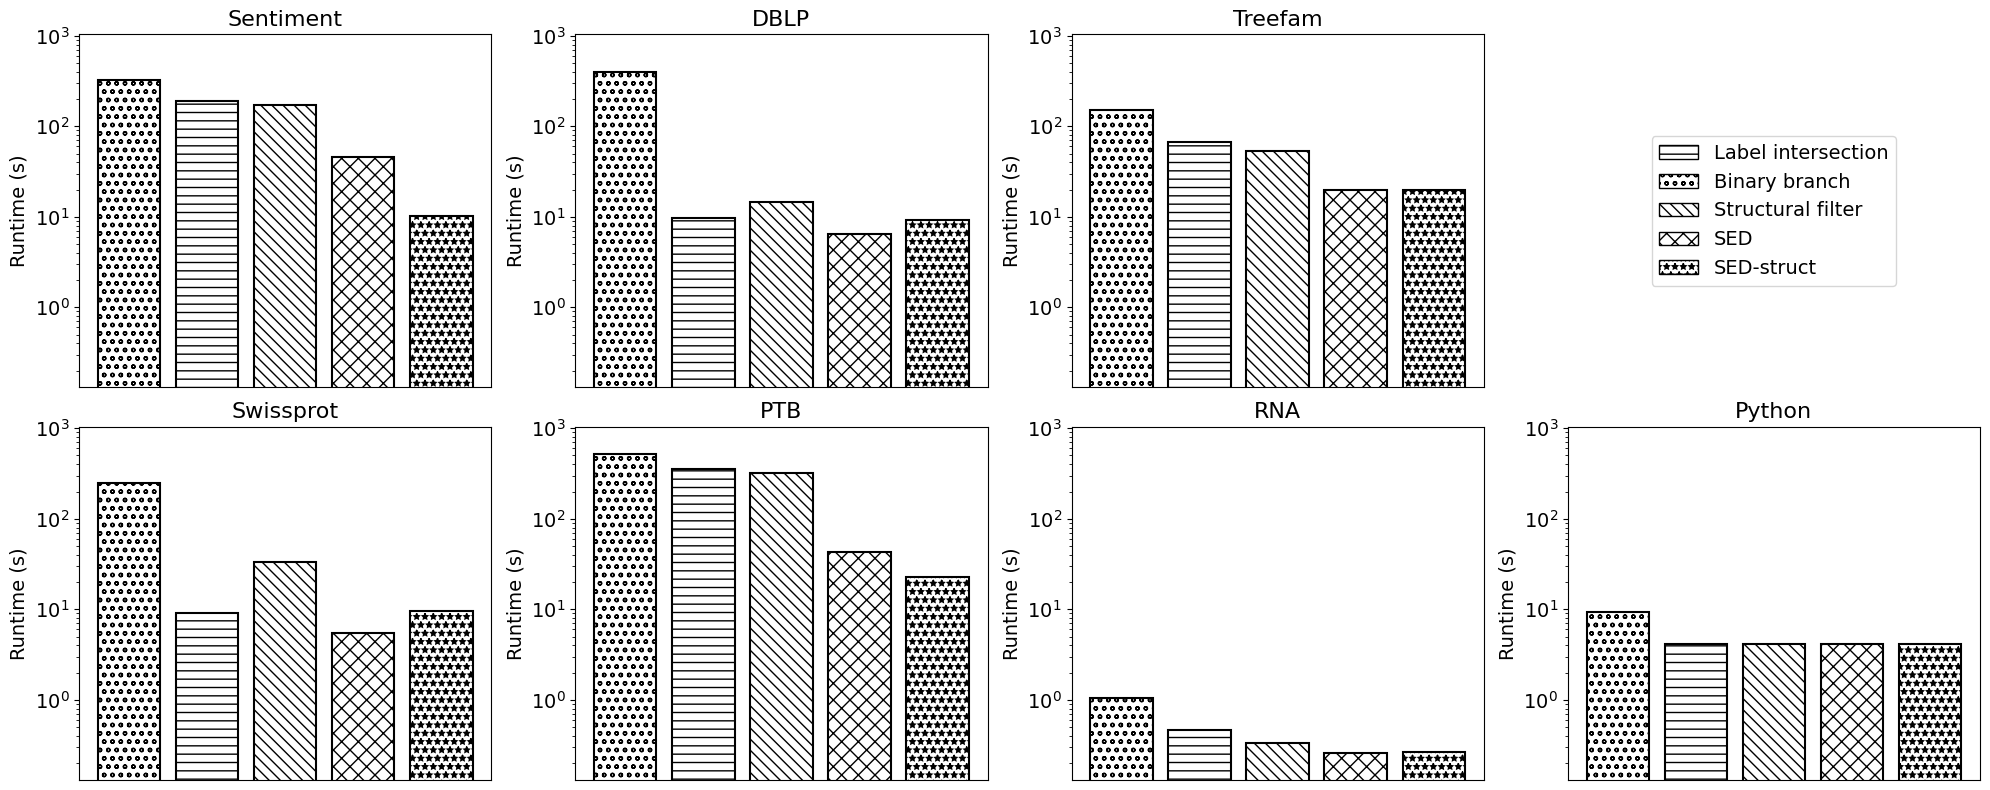

In [12]:
# calculate global min and max for normalization
global_min = filter_df['total_time_ms'].min() / 1000
global_max = filter_df['total_time_ms'].max() / 1000

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for idx, dataset in enumerate(real_datasets):
  dataset_data = filter_df[filter_df['dataset'] == (dataset.capitalize() if dataset not in ('dblp', 'rna', 'ptb') else dataset.upper())]
  ax = axes[idx + (1 if idx >= 3 else 0)]
  
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):
    bar = ax.bar(i, group['total_time_ms'].values[0] / 1000, color='white', edgecolor='black', linewidth=1.5, hatch=hatch_patterns[algorithm])
  
  ax.set_xticks([])
  ax.set_ylabel('Runtime (s)', fontsize=14)
  ax.tick_params(axis='y', labelsize=14)
  ax.set_title(dataset.capitalize() if dataset not in ('dblp', 'rna', 'ptb') else dataset.upper(), fontsize=16)
  ax.set_yscale('log')
  ax.set_ylim(global_min * 0.5, global_max * 2)

# Use the last subplot for the legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='white', edgecolor='black', hatch=hatch, label=alg) 
                   for alg, hatch in hatch_patterns.items()]

axes[3].axis('off')
axes[3].legend(handles=legend_elements, loc='center', fontsize=14, frameon=True)


plt.tight_layout()
plt.savefig('total_query_times_real_datasets.pdf', format='pdf')
plt.show()

In [14]:
filter_df.sort_values(['dataset', 'algorithm'])

,dataset,algorithm,filter_time_ms,verify_time_ms,precision,precision_percent,total_time_ms
0,DBLP,Binary branch,1366.0,397069.082,0.009639,0.963923,398435.082
7,DBLP,Label intersection,4126.0,5570.131,0.706752,70.675152,9696.131
20,DBLP,Structural filter,9323.0,5324.545,0.739407,73.940726,14647.545
27,DBLP,SED,3051.0,3888.244,0.998576,99.857556,6939.244
31,DBLP,SED-struct,5757.0,3888.244,0.998576,99.857556,9645.244
3,PTB,Binary branch,103.0,518164.174,0.017852,1.785230,518267.174
11,PTB,Label intersection,81.0,354294.921,0.028166,2.816617,354375.921
15,PTB,Structural filter,276.0,319536.118,0.031002,3.100203,319812.118
23,PTB,SED,1157.0,42327.906,0.214230,21.422979,43484.906
30,PTB,SED-struct,2563.0,20640.992,0.425674,42.567357,23203.992


/tmp/ipykernel_3864/1476591049.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):


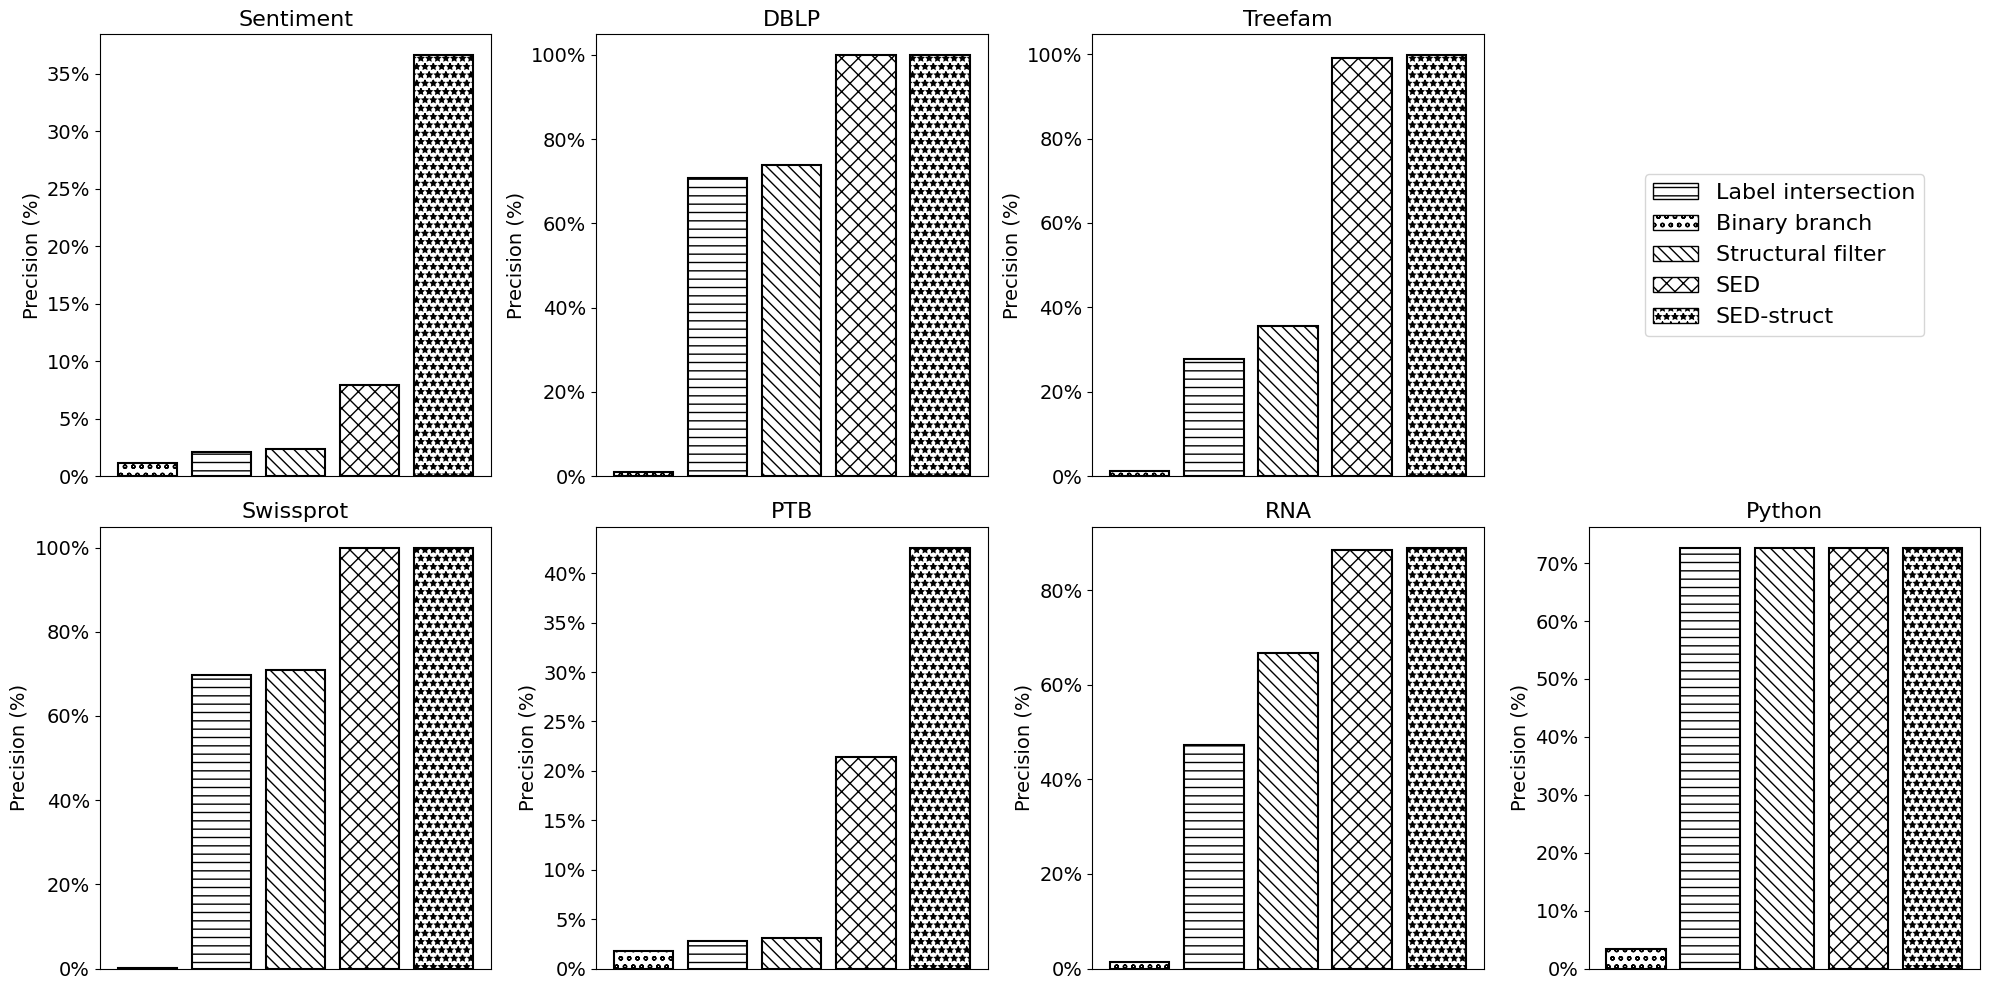

In [15]:
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, dataset in enumerate(real_datasets):
  dataset_name = dataset.capitalize() if dataset not in ('dblp', 'rna', 'ptb') else dataset.upper()
  dataset_data = filter_df[filter_df['dataset'] == dataset_name]
  ax = axes[idx + (1 if idx >= 3 else 0)]
  
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):
    val = group['precision_percent'].values[0]
    bar = ax.bar(i, val, color='white', edgecolor='black', linewidth=1.5, hatch=hatch_patterns[algorithm])
  
  ax.set_xticks([])
  ax.set_ylabel('Precision (%)', fontsize=14)
  
  # Conditional decimal formatting: only swissprot gets decimals
  decimals = 0
  ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=decimals))
  
  ax.tick_params(axis='y', labelsize=14)
  ax.set_title(dataset_name, fontsize=16)

# Use the last subplot for the legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='white', edgecolor='black', hatch=hatch, label=alg) 
                   for alg, hatch in hatch_patterns.items()]

axes[3].axis('off')
axes[3].legend(handles=legend_elements, loc='center', fontsize=16, frameon=True)

plt.tight_layout()
plt.savefig('precision_real_datasets.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Selectivity tests

In [11]:
selectivities_datasets
sel_ds = [(ds, f'selectivity-{sel}') for ds, sels in selectivities_datasets for sel in sels]
sel_ds

[('dblp', 'selectivity-2'),
 ('dblp', 'selectivity-3'),
 ('dblp', 'selectivity-5'),
 ('dblp', 'selectivity-10'),
 ('sentiment', 'selectivity-2'),
 ('sentiment', 'selectivity-3'),
 ('sentiment', 'selectivity-5'),
 ('sentiment', 'selectivity-10')]

In [14]:
# get datasets filterig times
filter_df = pd.DataFrame()

for selectivity_ds, selectivity in sel_ds:
  full_ds_name = join(selectivity_ds, selectivity)
  filter_df_ds = read_query_times(full_ds_name)
  filter_df_ds['dataset'] = selectivity_ds.capitalize() if selectivity_ds not in ('dblp', 'rna', 'ptb') else selectivity_ds.upper()
  filter_df_ds['selectivity'] = selectivity.split('-')[1]
  filter_df = pd.concat([filter_df, filter_df_ds], ignore_index=True)
filter_df['algorithm'] = pd.Categorical(filter_df['algorithm'], categories=algorithm_order, ordered=True)
filter_df = filter_df.sort_values(by=['dataset', 'selectivity', 'algorithm',])


# get datasets verifying times and precision
results_list = []

# Initialize new columns in filter_df if they don't exist
if 'verify_time_ms' not in filter_df.columns:
    filter_df['verify_time_ms'] = 0.0
if 'precision' not in filter_df.columns:
    filter_df['precision'] = 0.0
    

for selectivity_ds, selectivity in sel_ds:
  full_ds_name = join(selectivity_ds, selectivity)
  verify_file = join('datasets', full_ds_name, 'verified-all.csv')
  verify_df = pd.read_csv(verify_file, dtype={'query_id': 'int32', 'candidate_id': 'int32', 'verification_time_micro': 'float', 'final_ted': 'float', 'passed': 'bool'}, on_bad_lines='skip', engine='pyarrow')
  
  # Set multi-index for faster lookups - do this once per dataset
  verify_df = verify_df.set_index(['query_id', 'candidate_id'])
  
  for algorithm in ALGORITHMS.keys():
    alg = algorithm.capitalize() if algorithm != 'sedstruct' else 'SEDStruct'
    candidates_file = join('datasets', full_ds_name, f'{alg}_candidates.csv')
    if not exists(candidates_file):
      print(f'File not found: {candidates_file}')
      continue
    
    candidates_ds = pd.read_csv(candidates_file, header=None, dtype={'query_id': 'int32', 'candidate_id': 'int32'}, engine='pyarrow', names=['query_id', 'candidate_id'])
    
    # Set index on candidates and use join instead of merge (much faster)
    candidates_ds = candidates_ds.set_index(['query_id', 'candidate_id'])
    merged = candidates_ds.join(verify_df, how='inner')
    
    if not merged.empty:
      # Vectorized calculations
      passed_count = merged['passed'].sum()
      total_verify_time_ms = merged['verification_time_micro'].sum() / 1000.0
      precision = (passed_count / len(merged))
      
      # Format dataset name for the final lookup
      ds_display = selectivity_ds.capitalize() if selectivity_ds not in ('dblp', 'rna', 'ptb') else selectivity_ds.upper()
      
      # Store results for a single bulk update
      results_list.append({
          'dataset': ds_display,
          'selectivity': selectivity.split('-')[1],
          'algorithm': ALGORITHMS[algorithm],
          'verify_time_ms': total_verify_time_ms,
          'precision': precision
      })
        
      print(f'{algorithm} {passed_count}')
      
# One-shot update
results_df = pd.DataFrame(results_list)

new_filter_df = filter_df.set_index(['dataset', 'algorithm', 'selectivity'])
new_filter_df.update(results_df.set_index(['dataset', 'algorithm', 'selectivity']))
new_filter_df = new_filter_df.reset_index()
new_filter_df['precision_percent'] = new_filter_df['precision'] * 100
new_filter_df['total_time_ms'] = new_filter_df['verify_time_ms'] + new_filter_df['filter_time_ms']

structural 395313
sed 395313
lblint 395313
bib 395313
sedstruct 395313
structural 386396
sed 386396
lblint 386396
bib 386396
sedstruct 386396
structural 879597
sed 879597
lblint 879597
bib 879597
sedstruct 879597
structural 1651413
sed 1651413
lblint 1651413
bib 1651413
sedstruct 1651413
structural 157197
sed 157197
lblint 157197
bib 157197
sedstruct 157197
structural 205719
sed 205719
lblint 205719
bib 205719
sedstruct 205719
structural 239952
sed 239952
lblint 239952
bib 239952
sedstruct 239952
structural 322427
sed 322427
lblint 322427
bib 322427
sedstruct 322427


In [15]:
new_filter_df['precision_percent'] = new_filter_df['precision'] * 100
new_filter_df['total_time_ms'] = new_filter_df['verify_time_ms'] + new_filter_df['filter_time_ms']


/tmp/ipykernel_19400/4219756351.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):


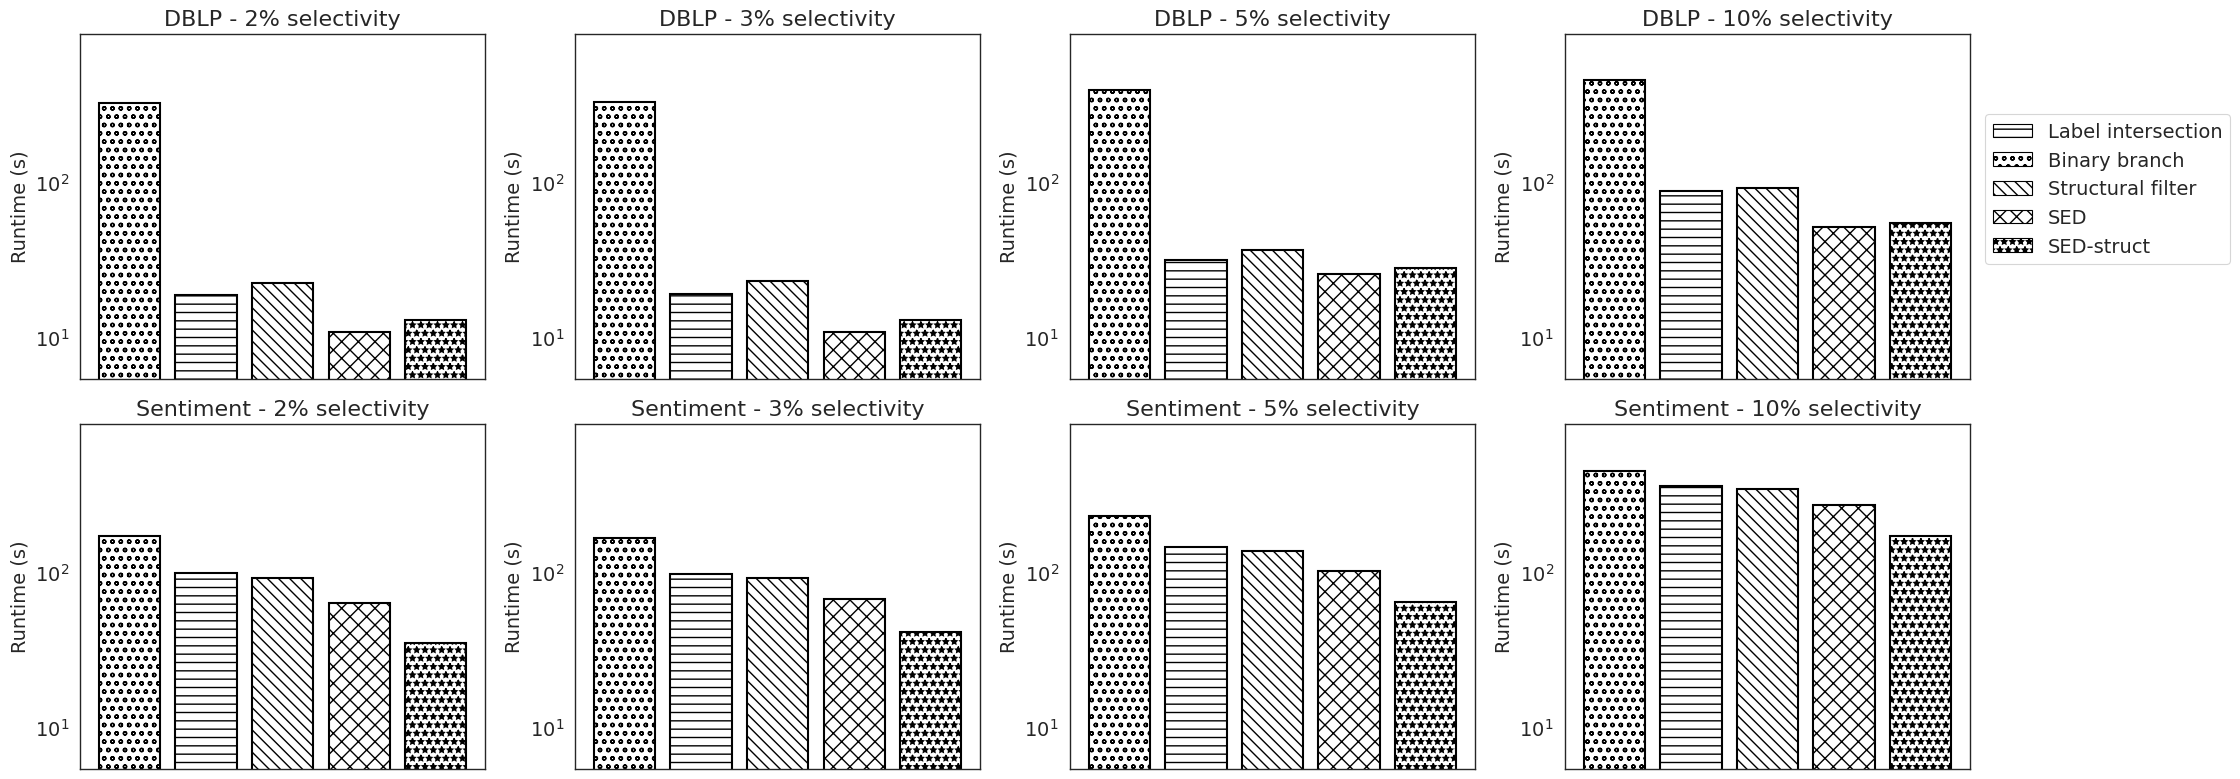

In [18]:
# calculate global min and max for normalization
global_min = new_filter_df['total_time_ms'].min() / 1000
global_max = new_filter_df['total_time_ms'].max() / 1000

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for idx, (dataset, selectivity_name) in enumerate(sel_ds):
  selectivity = selectivity_name.split('-')[1]
  dataset_data = new_filter_df[(new_filter_df['dataset'] == (dataset.capitalize() if dataset not in ('dblp', 'rna', 'ptb') else dataset.upper())) & (new_filter_df['selectivity'] == selectivity)]
  ax = axes[idx]
  
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):
    bar = ax.bar(i, group['total_time_ms'].values[0] / 1000, color='white', edgecolor='black', linewidth=1.5, hatch=hatch_patterns[algorithm])
  
  ax.set_xticks([])
  ax.set_ylabel('Runtime (s)', fontsize=14)
  ax.tick_params(axis='y', labelsize=14)
  title_ds = dataset.capitalize() if dataset not in ('dblp', 'rna', 'ptb') else dataset.upper()
  title_ds += f' - {selectivity}% selectivity'
  ax.set_title(title_ds, fontsize=16)
  ax.set_yscale('log')
  ax.set_ylim(global_min * 0.5, global_max * 2)

# Use the last subplot for the legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='white', edgecolor='black', hatch=hatch, label=alg) 
           for alg, hatch in hatch_patterns.items()]

fig.legend(handles=legend_elements, loc='right', bbox_to_anchor=(1.125, 0.75), ncol=1, fontsize=14, frameon=True)

plt.tight_layout()
plt.savefig('increasing_selectivity.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Ukkonen vs Regular SED tree sizes test

In [6]:
BASEPATH = 'ukkonen-vs-regular-sed-struct-test'

sizes = [10, 50, 100, 1000]
df = pd.DataFrame()

for ds in sizes:
    full_path = join(BASEPATH, f'avg-{ds}/collection.csv')
    tdf = pd.read_csv(full_path)
    df = pd.concat([df, tdf])
    
qdf = pd.DataFrame()

for ds in sizes:
    full_path_sed = join(BASEPATH, f'avg-{ds}/query-sed-regular.csv')
    full_path_sedstruct = join(BASEPATH, f'avg-{ds}/query-sed-ukkonen.csv')
    # read second line of file
    with open(full_path_sed) as f:
        lines = f.readlines()
        reg_time = float(lines[1].strip('ms\n').split(':')[1])
    with open(full_path_sedstruct) as f:
        lines = f.readlines()
        uk_time = float(lines[1].strip('ms\n').split(':')[1])
    tdf = pd.DataFrame({
        'TreeSize': [ds] * 2,
        'Method': ['Regular', 'Ukkonen'],
        'SearchTime': [reg_time, uk_time]
    })
    qdf = pd.concat([qdf, tdf])

for ds in sizes:
    full_path_sed = join(BASEPATH, f'avg-{ds}/verification-sed-times.csv')
    tdf = pd.read_csv(full_path_sed, skipfooter=1, engine='python')
    

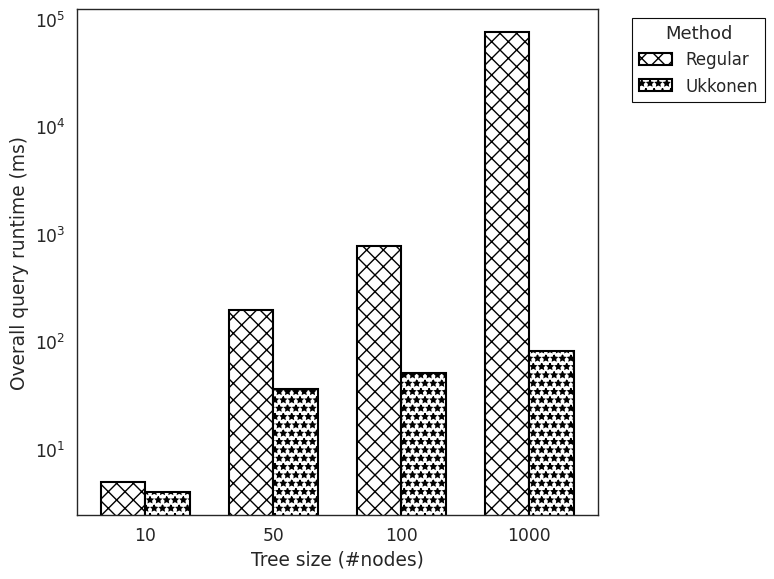

In [7]:
# Set publication-quality theme
sns.set_context("paper", font_scale=1.4)
sns.set_style("white", {
    'axes.edgecolor': '.15',
    'axes.linewidth': 1.25
})

# Define hatch patterns for methods
method_hatch_patterns = {
    'Regular': 'xx',
    'Ukkonen': '**'
}

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Get unique tree sizes and methods
tree_sizes = qdf['TreeSize'].unique()
methods = qdf['Method'].unique()

# Set up bar positions
x = np.arange(len(tree_sizes))
width = 0.35

# Plot bars for each method
for i, method in enumerate(methods):
    method_data = qdf[qdf['Method'] == method]
    values = [method_data[method_data['TreeSize'] == ts]['SearchTime'].values[0] for ts in tree_sizes]
    ax.bar(x + i * width, values, width, color='white', edgecolor='black', 
           linewidth=1.5, hatch=method_hatch_patterns[method], label=method)

ax.set_yscale('log')
ax.set_ylabel('Overall query runtime (ms)')
ax.set_xlabel('Tree size (#nodes)')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(tree_sizes)
ax.tick_params(axis='y')

# Improve legend and place it outside the plot
ax.legend(
    title='Method',
    title_fontsize=13,
    fontsize=12,
    frameon=True,
    fancybox=False,
    edgecolor='black',
    framealpha=0.95,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.savefig('ukkonen_vs_regular_sed_search_times.pdf', format='pdf', bbox_inches='tight')
plt.show()


# Collection statistics

In [8]:
full_df = pd.DataFrame()

ukkonen_test_datasets = [
  'avg-10',
  'avg-50',
  'avg-100',
  'avg-1000',
]

for ds in real_datasets + label_datasets + fanout_datasets:
    full_path_weighted_branch_factor = join('datasets', ds, 'statistics', 'weighted_branching_shallow_factor.csv')
    fanout_file = join('datasets', ds, 'statistics', 'avg_fanout.csv')
    
    tdf = pd.read_csv(full_path_weighted_branch_factor, engine='pyarrow', names=['branching_factor'], dtype={'branching_factor': 'float'})
    fdf = pd.read_csv(fanout_file, engine='pyarrow', names=['fanout'], dtype={'fanout': 'float'})
    tdf['dataset'] = ds.capitalize() if ds not in ('dblp', 'rna', 'ptb') else ds.upper()
    merged_df = pd.concat([tdf, fdf], axis=1)

    # fdf['dataset'] = ds.capitalize() if ds not in ('dblp', 'rna', 'ptb') else ds.upper()
    # temp_df = pd.concat([fdf, tdf])
    full_df = pd.concat([full_df, merged_df], ignore_index=True)
    
    
for ds in ukkonen_test_datasets:
    full_path_weighted_branch_factor = join('ukkonen-vs-regular-sed-struct-test', ds, 'statistics', 'weighted_branching_shallow_factor.csv')
    fanout_file = join('ukkonen-vs-regular-sed-struct-test', ds, 'statistics', 'avg_fanout.csv')
    
    tdf = pd.read_csv(full_path_weighted_branch_factor, engine='pyarrow', names=['branching_factor'], dtype={'branching_factor': 'float'})
    fdf = pd.read_csv(fanout_file, engine='pyarrow', names=['fanout'], dtype={'fanout': 'float'})
    tdf['dataset'] = ds.capitalize() if ds not in ('dblp', 'rna', 'ptb') else ds.upper()
    merged_df = pd.concat([tdf, fdf], axis=1)

    # fdf['dataset'] = ds.capitalize() if ds not in ('dblp', 'rna', 'ptb') else ds.upper()
    # temp_df = pd.concat([fdf, tdf])
    full_df = pd.concat([full_df, merged_df], ignore_index=True)
        
full_df

,branching_factor,dataset,fanout
0,1.000000,Sentiment,1.000000
1,1.000000,Sentiment,1.000000
2,1.000000,Sentiment,1.000000
3,1.000000,Sentiment,1.000000
4,1.000000,Sentiment,1.000000
...,...,...,...
524773,0.183271,Avg-1000,2.370283
524774,0.196492,Avg-1000,2.353630
524775,0.204212,Avg-1000,2.421687
524776,0.204726,Avg-1000,2.427536


/tmp/ipykernel_21862/2637606783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.boxplot(data=full_df, x='dataset', y='branching_factor', palette='Set2')


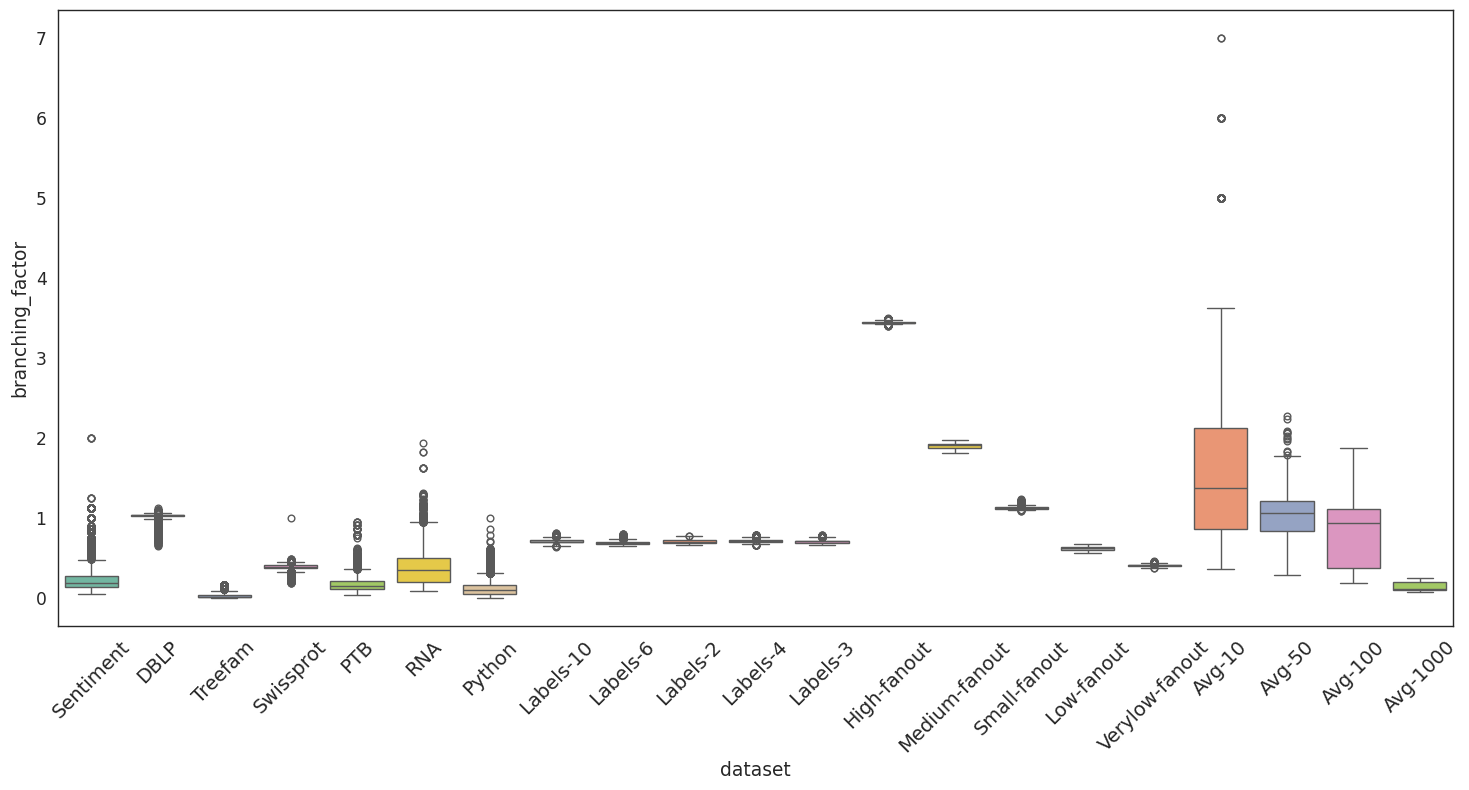

In [9]:
fig = plt.figure(figsize=(18, 8))
ax =sns.boxplot(data=full_df, x='dataset', y='branching_factor', palette='Set2')

ax.tick_params(axis='x', rotation=45, labelsize=14)

/tmp/ipykernel_21862/487993234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.boxplot(data=full_df, x='dataset', y='fanout', palette='Set2')


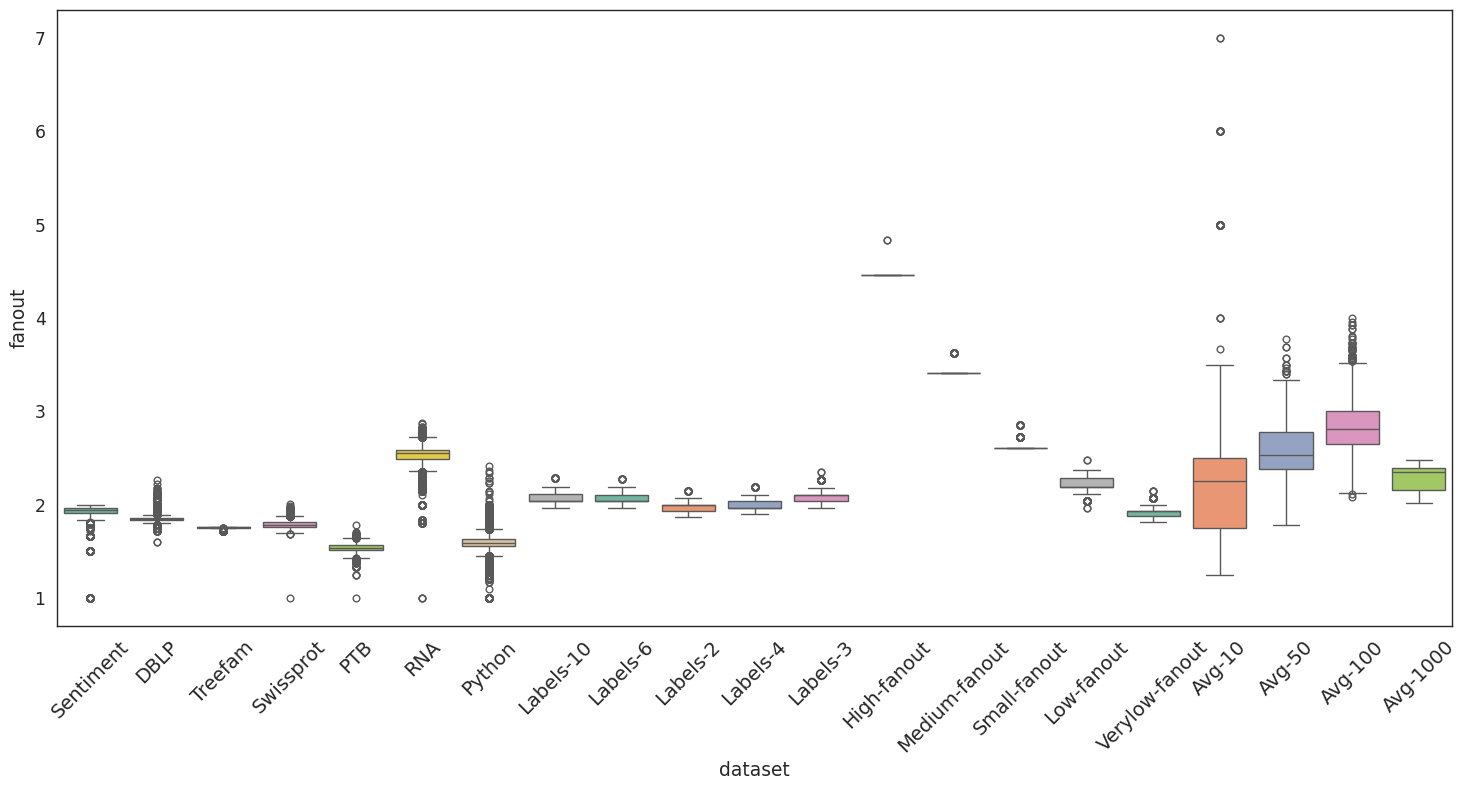

In [10]:
fig = plt.figure(figsize=(18, 8))
ax =sns.boxplot(data=full_df, x='dataset', y='fanout', palette='Set2')

ax.tick_params(axis='x', rotation=45, labelsize=14)

In [11]:
gdf = full_df.groupby('dataset').agg({'branching_factor': ['mean', 'std', 'min', 'max'], 'fanout': ['mean', 'std', 'min', 'max']})
gdf = gdf.reindex([ds.capitalize() if ds not in ('dblp', 'rna', 'ptb') else ds.upper() for ds in real_datasets + label_datasets + fanout_datasets + ukkonen_test_datasets])
gdf


branching_factor                                  fanout  \
                           mean       std       min       max      mean   
dataset                                                                   
Sentiment              0.240059  0.167809  0.058799  2.000000  1.918636   
DBLP                   1.025370  0.028531  0.647891  1.125000  1.849134   
Treefam                0.032519  0.032280  0.004350  0.162230  1.754566   
Swissprot              0.392689  0.023559  0.187597  1.000000  1.787042   
PTB                    0.181223  0.106093  0.040278  0.949074  1.535779   
RNA                    0.373798  0.190791  0.096728  1.937500  2.515692   
Python                 0.136348  0.113750  0.008115  1.000000  1.591756   
Labels-10              0.712947  0.021902  0.646330  0.812327  2.069446   
Labels-6               0.692717  0.020943  0.657004  0.805186  2.067815   
Labels-2               0.711896  0.021344  0.660259  0.780268  1.985546   
Labels-4               0.717255  0.017433  0.665403  0.796095  1.996781   
Labels-3               0.711640  0.020277  0.660602  0.785869  2.102722   
High-fanout            3.448934  0.012758  3.405726  3.501677  4.461687   
Medium-fanout          1.907406  0.030096  1.816993  1.980469  3.413129   
Small-fanout           1.134460  0.021816  1.093611  1.235622  2.636874   
Low-fanout             0.622752  0.022097  0.564182  0.681740  2.213039   
Verylow-fanout         0.411896  0.010370  0.379462  0.460770  1.924084   
Avg-10                 1.602424  1.088157  0.367847  7.000000  2.361682   
Avg-50                 1.023445  0.330309  0.286357  2.279380  2.588978   
Avg-100                0.795584  0.405898  0.189250  1.877433  2.831854   
Avg-1000               0.146181  0.050025  0.082714  0.252501  2.287183   

                                              
                     std       min       max  
dataset                                       
Sentiment       0.092220  1.000000  2.000000  
DBLP            0.024228  1.600000  2.260870  
Treefam         0.007560  1.717949  1.765049  
Swissprot       0.033425  1.000000  2.004831  
PTB             0.046585  1.000000  1.777778  
RNA             0.127685  1.000000  2.875000  
Python          0.104038  1.000000  2.410714  
Labels-10       0.053388  1.965517  2.280000  
Labels-6        0.045753  1.966667  2.269231  
Labels-2        0.048016  1.870968  2.148148  
Labels-4        0.047014  1.903226  2.185185  
Labels-3        0.053212  1.967742  2.346154  
High-fanout     0.007435  4.461538  4.833333  
Medium-fanout   0.017006  3.411765  3.625000  
Small-fanout    0.051925  2.608696  2.857143  
Low-fanout      0.071385  1.965517  2.478261  
Verylow-fanout  0.044997  1.818182  2.142857  
Avg-10          0.862545  1.250000  7.000000  
Avg-50          0.317725  1.785714  3.769231  
Avg-100         0.305911  2.081633  4.000000  
Avg-1000        0.139280  2.020243  2.481297

# Synthetic datasets - SED vs SED-struct

high-fanout
medium-fanout
small-fanout
low-fanout
verylow-fanout


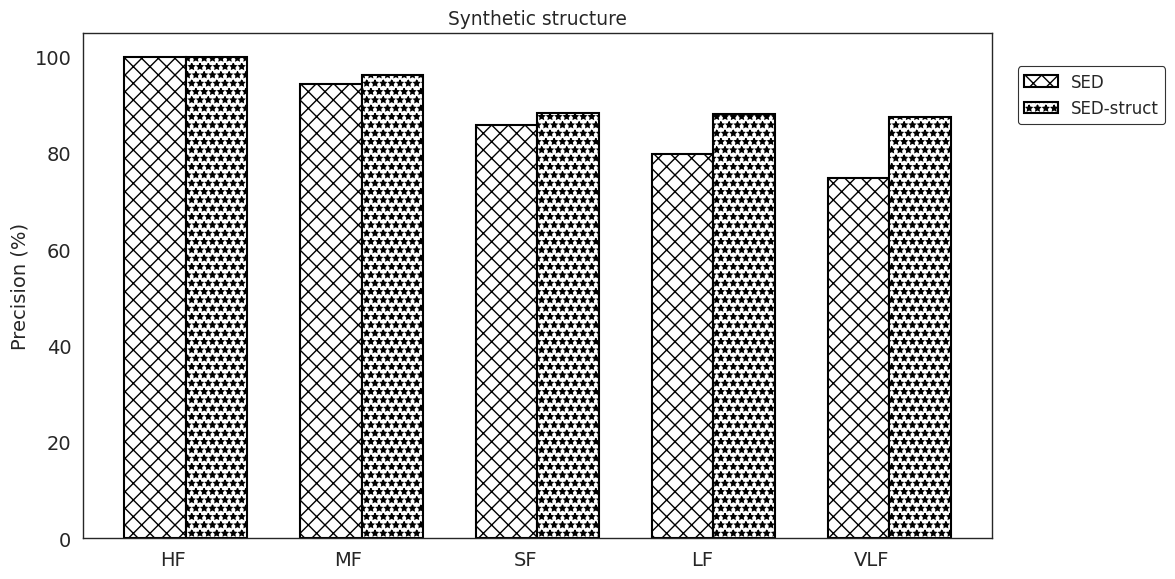

labels-10
labels-6
labels-2
labels-4
labels-3


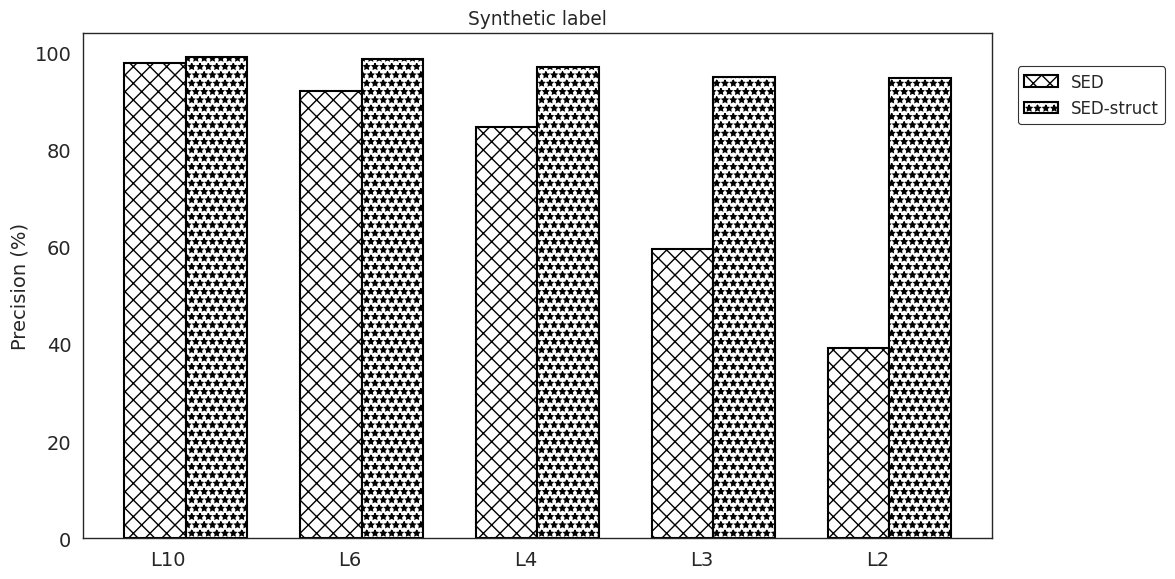

In [12]:

BASEPATH = 'datasets/'


# For label datasets
label_order = {'labels-10': 0, 'labels-6': 1, 'labels-4': 2, 'labels-3': 3, 'labels-2': 4}
renames = {'labels-10': 'L10', 'labels-6': 'L6', 'labels-4': 'L4', 'labels-3': 'L3', 'labels-2': 'L2',
           'high-fanout': 'HF', 'medium-fanout': 'MF', 'small-fanout': 'SF', 'low-fanout': 'LF', 'verylow-fanout': 'VLF'}
fanout_order = {'high': 0, 'medium': 1, 'small': 2, 'low': 3, 'verylow': 4}

def get_precision_plot_with_order(datasets: list[str], order_map: dict, pattern: str, ax):
  qdf = pd.DataFrame()
  for ds in datasets:
      full_path_sed = join(BASEPATH, f'{ds}/query-sed-ukkonen.csv')
      full_path_sedstruct = join(BASEPATH, f'{ds}/query-sed-struct-ukkonen.csv')
      # read second line of file
      with open(full_path_sed) as f:
          lines = f.readlines()
          reg_time = float(lines[1].strip('ms\n').split(':')[1])
      with open(full_path_sedstruct) as f:
          lines = f.readlines()
          uk_time = float(lines[1].strip('ms\n').split(':')[1])
      tdf = pd.DataFrame({
          'Dataset': [ds] * 2,
          'Method': ['SED', 'SED-struct'],
          'SearchTime': [reg_time, uk_time]
      })
      qdf = pd.concat([qdf, tdf])

  all_sed_candidates = pd.DataFrame()
  all_sedstruct_candidates = pd.DataFrame()
  for ds in datasets:
    sed_candidates = pd.read_csv(join(BASEPATH, f'{ds}/Sed_candidates.csv'), header=None, names=['query_id', 'candidate_id'])
    sedstruct_candidates = pd.read_csv(join(BASEPATH, f'{ds}/SEDStruct_candidates.csv'), header=None, names=['query_id', 'candidate_id'])
    sed_candidates.insert(0, 'Dataset', ds)
    sedstruct_candidates.insert(0, 'Dataset', ds)
    all_sed_candidates = pd.concat([all_sed_candidates, sed_candidates])
    all_sedstruct_candidates = pd.concat([all_sedstruct_candidates, sedstruct_candidates])
      
  all_vdf = pd.DataFrame()
  for ds in datasets:
    print(ds)
    vdf = pd.read_csv(join(BASEPATH, f'{ds}/verified-all.csv'), engine="pyarrow",  on_bad_lines='skip')
    vdf.insert(0, 'Dataset', ds)
    all_vdf = pd.concat([all_vdf, vdf])
      
  sed_joined = all_sed_candidates.merge(all_vdf, on=['Dataset', 'query_id', 'candidate_id'], how='inner')
  sedstruct_joined = all_sedstruct_candidates.merge(all_vdf, on=['Dataset', 'query_id', 'candidate_id'], how='inner')

  # Calculate verification times for each dataset separately
  for dataset in datasets:
      sed_dataset_time = sed_joined[sed_joined['Dataset'] == dataset]['verification_time_micro'].sum() / 1000
      sedstruct_dataset_time = sedstruct_joined[sedstruct_joined['Dataset'] == dataset]['verification_time_micro'].sum() / 1000
      
      # Update the qdf dataframe for each dataset
      qdf.loc[(qdf['Dataset'] == dataset) & (qdf['Method'] == 'SED'), 'VerificationTime'] = sed_dataset_time
      qdf.loc[(qdf['Dataset'] == dataset) & (qdf['Method'] == 'SED-struct'), 'VerificationTime'] = sedstruct_dataset_time
      
  # Get SED precision
  sed_precision = all_sed_candidates.groupby('Dataset').size().reset_index(name='SED_Total')
  sed_passed = all_vdf[all_vdf['passed'] == 1].groupby('Dataset').size().reset_index(name='SED_Passed')
  sed_precision = sed_precision.merge(sed_passed, on='Dataset', how='left').fillna(0)
  sed_precision['Method'] = 'SED'
  sed_precision['Precision'] = (sed_precision['SED_Passed'] / sed_precision['SED_Total']) * 100

  #  Get SEDStruct precision
  sedstruct_precision = all_sedstruct_candidates.groupby('Dataset').size().reset_index(name='SEDStruct_Total')
  sedstruct_passed = all_vdf[all_vdf['passed'] == 1].groupby('Dataset').size().reset_index(name='SEDStruct_Passed')
  sedstruct_precision = sedstruct_precision.merge(sedstruct_passed, on='Dataset', how='left').fillna(0)
  sedstruct_precision['Method'] = 'SED-struct'
  sedstruct_precision['Precision'] = (sedstruct_precision['SEDStruct_Passed'] / sedstruct_precision['SEDStruct_Total']) * 100

  # Combine results
  precision_df = pd.concat([
      sed_precision[['Dataset', 'Method', 'SED_Total', 'SED_Passed', 'Precision']].rename(columns={'SED_Total': 'Total', 'SED_Passed': 'Passed'}),
      sedstruct_precision[['Dataset', 'Method', 'SEDStruct_Total', 'SEDStruct_Passed', 'Precision']].rename(columns={'SEDStruct_Total': 'Total', 'SEDStruct_Passed': 'Passed'})
  ])

  # Create grouped bar plot
  method_hatch = {
      'SED': 'xx',
      'SED-struct': '**'
  }
  
  datasets_list = precision_df['Dataset'].unique()
  
  # Sort datasets_list based on the order_map
  def get_sort_order(ds_name):
    for key, order in order_map.items():
      if pattern.format(key) in ds_name:
        return order
    return 999
  
  datasets_list = sorted(datasets_list, key=get_sort_order)
  methods = precision_df['Method'].unique()
  
  x = np.arange(len(datasets_list))
  width = 0.35
  
  
  for i, method in enumerate(methods):
    method_data = precision_df[precision_df['Method'] == method]
    values = [method_data[method_data['Dataset'] == ds]['Precision'].values[0] for ds in datasets_list]
    ax.bar(x + i * width, values, width, color='white', edgecolor='black', 
           linewidth=1.5, hatch=method_hatch[method], label=method)
  
  ax.set_ylabel('Precision (%)', fontsize=14)
  ax.set_xticks(x + width / 2)
  renamed_labels = [renames.get(ds, ds) for ds in datasets_list]
  ax.set_xticklabels(renamed_labels, rotation=0, ha='right', fontsize=14)
  ax.tick_params(axis='y', labelsize=14)

# First figure - fanout datasets
fig1, ax1 = plt.subplots(1, 1, figsize=(12, 6))
get_precision_plot_with_order(fanout_datasets, fanout_order, '{}', ax1)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.20, 0.95), fontsize=12, frameon=True, edgecolor='black')
ax1.set_title('Synthetic structure')
plt.tight_layout()
plt.savefig('synthetic_precision_structure.pdf')
plt.show()

# Second figure - label datasets
fig2, ax2 = plt.subplots(1, 1, figsize=(12, 6))
get_precision_plot_with_order(label_datasets, label_order, '{}', ax2)
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.20, 0.95), fontsize=12, frameon=True, edgecolor='black')
ax2.set_title('Synthetic label')
plt.tight_layout()
plt.savefig('synthetic_precision_label.pdf')
plt.show()


In [13]:
path = 'datasets/sentiment/verified-all.csv'

df = pd.read_csv(path, engine='pyarrow', on_bad_lines='skip')


df.head()

,query_id,candidate_id,verification_time_micro,final_ted,passed
0,7,58,2,inf,0
1,99,9644,1,inf,0
2,99,9643,1,inf,0
3,99,9642,1,inf,0
4,42,5791,169,inf,0


In [14]:
df[df['passed'] == 1]

,query_id,candidate_id,verification_time_micro,final_ted,passed
470,19,1081,114,29.0,1
516,19,3490,199,29.0,1
619,23,3517,160,30.0,1
1114,15,2281,407,29.0,1
1200,42,5790,211,29.0,1
...,...,...,...,...,...
963498,99,3830,202,29.0,1
963818,99,3814,197,29.0,1
963822,95,5014,200,30.0,1
964018,99,3804,165,28.0,1


# Traversals tests

In [15]:
datasets = ['sentiment', 'rna', 'labels-4', 'high-fanout']

traversals_combinations=(
  ("preorder","postorder"),
  ("reversed-postorder","preorder"),
  ("reversed-postorder","postorder"),
  ("reversed-preorder","preorder"),
  ("reversed-preorder","postorder"),
  ("reversed-postorder","reversed-preorder"),
)

def full_dir(dataset, traversal_pair: tuple[str, str]):
  return join('datasets', dataset, 'traversals', f'{traversal_pair[0]}---{traversal_pair[1]}')

In [16]:
# load all traversal candidates into a single dataframe
traversal_df = pd.DataFrame()
result_df = pd.DataFrame()
for dataset in datasets:
  for traversal_pair in traversals_combinations:
    dir_path = full_dir(dataset, traversal_pair)
    if not exists(dir_path):
      print(f'Directory not found: {dir_path}')
      continue
    
    file_path = join(dir_path, 'Sed_candidates.csv')
    sed_df = pd.read_csv(file_path, engine='pyarrow', header=None, names=['query_id', 'candidate_id'])
    sed_df['dataset'] = dataset
    sed_df['method'] = 'SED'
    sed_df['traversal'] = f'{traversal_pair[0]}---{traversal_pair[1]}'
    traversal_df = pd.concat([traversal_df, sed_df], ignore_index=True)
    
    file_path = join(dir_path, 'SEDStruct_candidates.csv')
    sed_df = pd.read_csv(file_path, engine='pyarrow', header=None, names=['query_id', 'candidate_id'])
    sed_df['dataset'] = dataset
    sed_df['method'] = 'SEDStruct'
    sed_df['traversal'] = f'{traversal_pair[0]}---{traversal_pair[1]}'
    traversal_df = pd.concat([traversal_df, sed_df], ignore_index=True)
    
display(traversal_df.head())
# print loaded datasets and traversal pairs
print(traversal_df[['dataset']].drop_duplicates())

,query_id,candidate_id,dataset,method,traversal
0,0,839,sentiment,SED,preorder---postorder
1,0,884,sentiment,SED,preorder---postorder
2,0,908,sentiment,SED,preorder---postorder
3,0,1081,sentiment,SED,preorder---postorder
4,0,1096,sentiment,SED,preorder---postorder


             dataset
0          sentiment
1288755          rna
1622409     labels-4
1705363  high-fanout


In [17]:
verified_all_df = pd.DataFrame()

for real_ds in datasets:
  verify_file = join('datasets', real_ds, 'verified-all.csv')
  verify_df = pd.read_csv(verify_file, dtype={'query_id': 'int32', 'candidate_id': 'int32', 'verification_time_micro': 'float', 'final_ted': 'float', 'passed': 'bool'}, on_bad_lines='skip', engine='pyarrow')
  
  # Set multi-index for faster lookups - do this once per dataset
  verify_df = verify_df.set_index(['query_id', 'candidate_id'])
  verify_df['dataset'] = real_ds
  verified_all_df = pd.concat([verified_all_df, verify_df.reset_index()], ignore_index=True)


In [18]:
verified_all_df.head()

,query_id,candidate_id,verification_time_micro,final_ted,passed,dataset
0,7,58,2.0,inf,False,sentiment
1,99,9644,1.0,inf,False,sentiment
2,99,9643,1.0,inf,False,sentiment
3,99,9642,1.0,inf,False,sentiment
4,42,5791,169.0,inf,False,sentiment


In [19]:
keys = ['query_id', 'candidate_id', 'dataset']


# If verified has duplicate key rows, keep one
merged = traversal_df.merge(
    verified_all_df,
    on=keys,
    # how='left',            # keeps all candidate rows
    # validate='many_to_one' # candidate rows -> one verified row per key
)

# Missing verified rows become not passed (adjust if your logic differs)
# merged['passed'] = merged['passed'].fillna(0).astype('int8')

# detect any NA values in the merged dataframe
if merged.isna().any().any():
    print("Warning: NA values detected in merged dataframe")
    print(merged[merged.isna().any(axis=1)])
    


In [20]:
# for each dataset, method and traversal, calculate precision and total verification time
results = []
for (dataset, method, traversal), group in merged.groupby(['dataset', 'method', 'traversal']):
    total_candidates = len(group)
    passed_candidates = group['passed'].sum()
    precision = (passed_candidates / total_candidates) * 100 if total_candidates > 0 else 0
    total_verification_time_ms = group['verification_time_micro'].sum() / 1000
    results.append({
        'dataset': dataset,
        'method': method,
        'traversal': traversal,
        'precision_percent': precision,
        'total_verification_time_ms': total_verification_time_ms
    })
    
print(results)
    
results_df = pd.DataFrame(results)
results_df.head(15)

[{'dataset': 'high-fanout', 'method': 'SED', 'traversal': 'preorder---postorder', 'precision_percent': np.float64(100.0), 'total_verification_time_ms': np.float64(169.212)}, {'dataset': 'high-fanout', 'method': 'SED', 'traversal': 'reversed-postorder---postorder', 'precision_percent': np.float64(100.0), 'total_verification_time_ms': np.float64(169.212)}, {'dataset': 'high-fanout', 'method': 'SED', 'traversal': 'reversed-postorder---preorder', 'precision_percent': np.float64(100.0), 'total_verification_time_ms': np.float64(169.212)}, {'dataset': 'high-fanout', 'method': 'SED', 'traversal': 'reversed-postorder---reversed-preorder', 'precision_percent': np.float64(100.0), 'total_verification_time_ms': np.float64(169.212)}, {'dataset': 'high-fanout', 'method': 'SED', 'traversal': 'reversed-preorder---postorder', 'precision_percent': np.float64(100.0), 'total_verification_time_ms': np.float64(169.212)}, {'dataset': 'high-fanout', 'method': 'SED', 'traversal': 'reversed-preorder---preorder',

,dataset,method,traversal,precision_percent,total_verification_time_ms
0,high-fanout,SED,preorder---postorder,100.000000,169.212
1,high-fanout,SED,reversed-postorder---postorder,100.000000,169.212
2,high-fanout,SED,reversed-postorder---preorder,100.000000,169.212
3,high-fanout,SED,reversed-postorder---reversed-preorder,100.000000,169.212
4,high-fanout,SED,reversed-preorder---postorder,100.000000,169.212
5,high-fanout,SED,reversed-preorder---preorder,100.000000,169.212
6,high-fanout,SEDStruct,preorder---postorder,100.000000,169.212
7,high-fanout,SEDStruct,reversed-postorder---postorder,100.000000,169.212
8,high-fanout,SEDStruct,reversed-postorder---preorder,100.000000,169.212
9,high-fanout,SEDStruct,reversed-postorder---reversed-preorder,100.000000,169.212


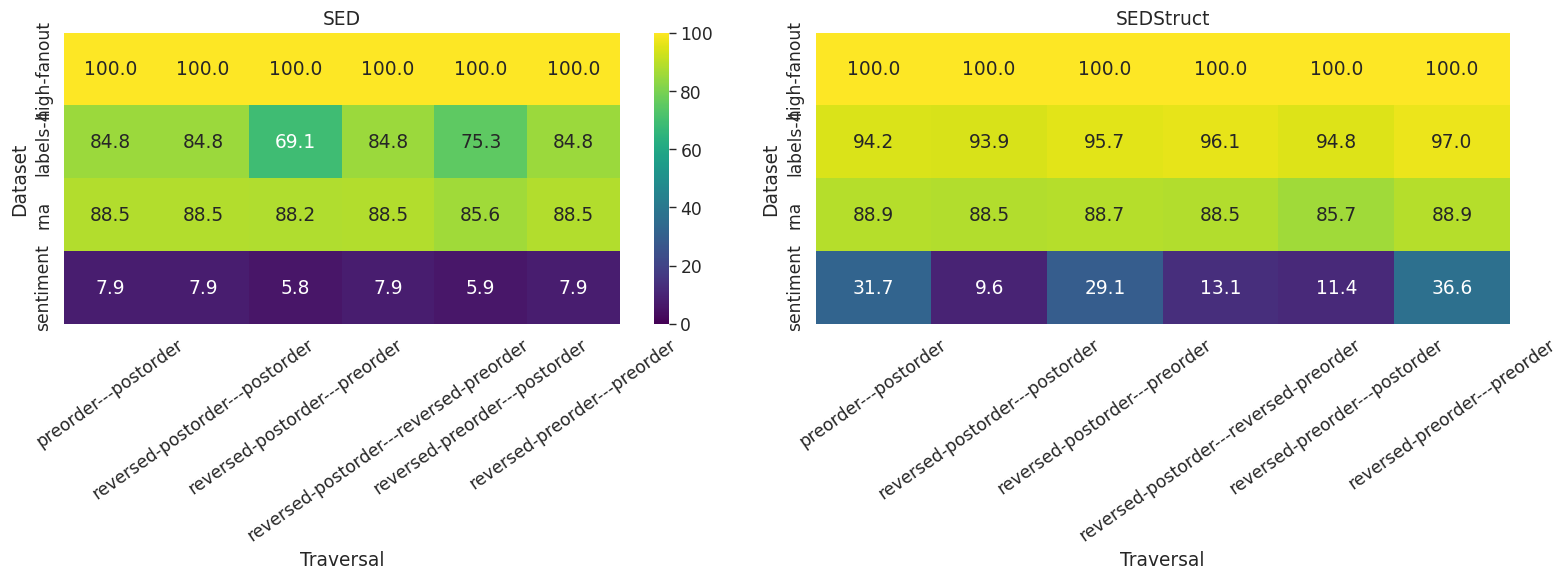

In [21]:
# Optional ordering
traversal_order = sorted(results_df['traversal'].unique())
dataset_order = sorted(results_df['dataset'].unique())
method_order = sorted(results_df['method'].unique())

vmin, vmax = 0, 100  # keep fixed across facets for fair comparison

n = len(method_order)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8*ncols, 6*nrows), squeeze=False)

for i, method in enumerate(method_order):
    r, c = divmod(i, ncols)
    ax = axes[r][c]
    pivot = (results_df[results_df['method'] == method]
             .pivot_table(index='dataset', columns='traversal',
                          values='precision_percent', aggfunc='mean')
             .reindex(index=dataset_order, columns=traversal_order))
    sns.heatmap(
        pivot, ax=ax, cmap='viridis', vmin=vmin, vmax=vmax,
        annot=True, fmt=".1f", cbar=(i == 0)
    )
    ax.set_title(method)
    ax.set_xlabel("Traversal")
    ax.set_ylabel("Dataset")
    ax.tick_params(axis='x', rotation=35)

# hide empty axes
for j in range(i + 1, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r][c].axis('off')

plt.tight_layout()
plt.show()

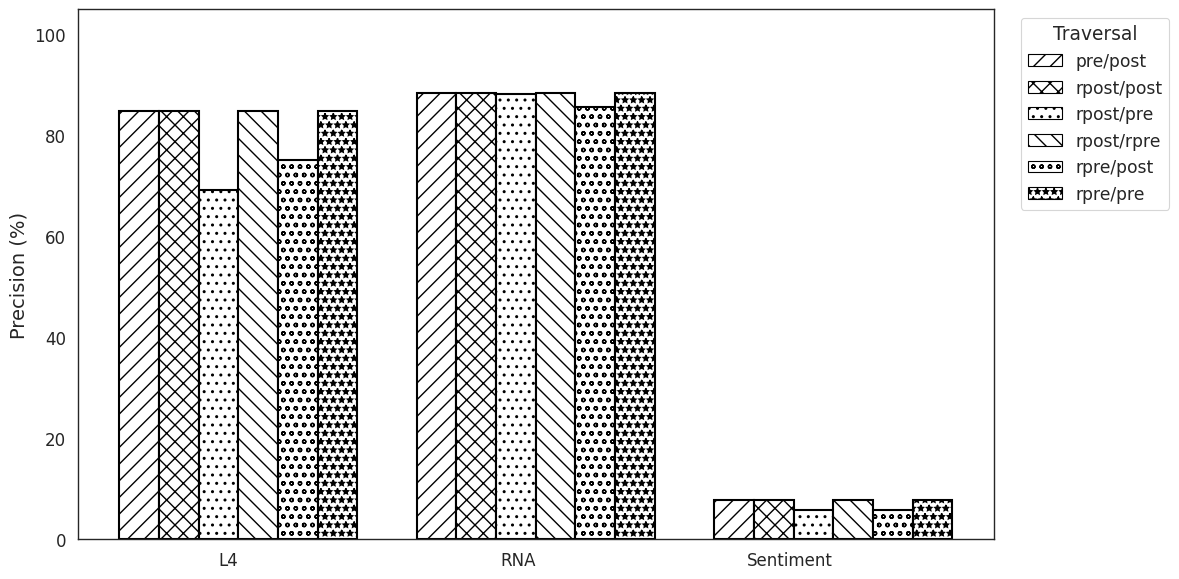

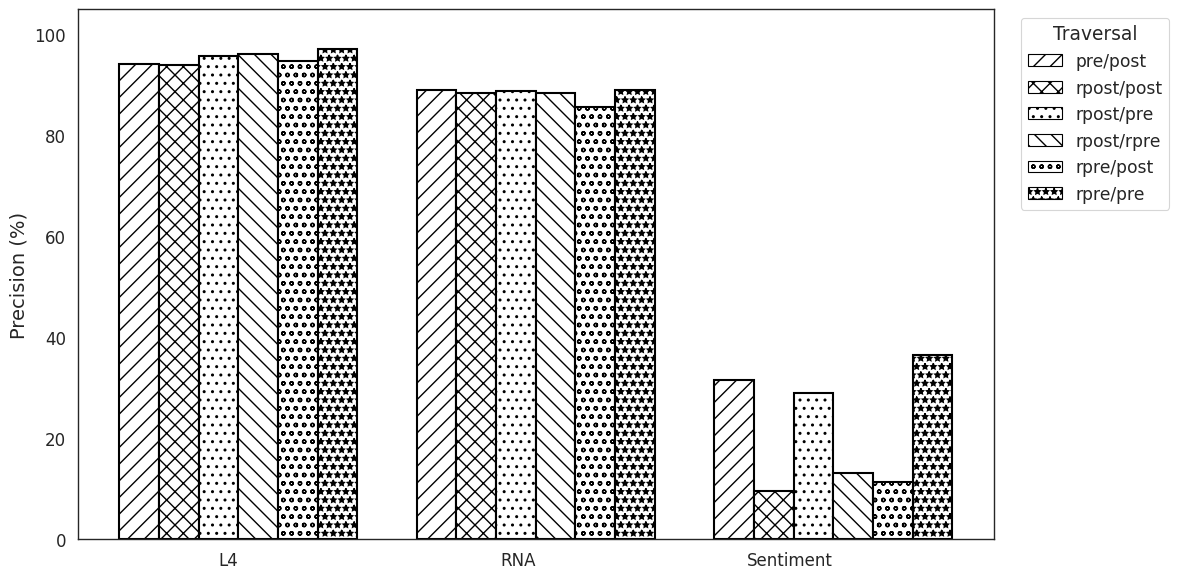

In [24]:
# Bar plot alternative: one separate chart per method (no facet)
plot_df = results_df[results_df['dataset'] != 'high-fanout'].copy()
plot_df['dataset'] = plot_df['dataset'].replace({'labels-4': 'L4'})

# Optional ordering to keep plots stable
traversal_order = sorted(plot_df['traversal'].unique())
dataset_order = sorted(plot_df['dataset'].unique())
method_order = sorted(plot_df['method'].unique())



# Helper function to format traversal label for display
def format_traversal_label(traversal_str):
    """Format traversal string for display."""
    result = traversal_str
    # Do longer patterns first to avoid partial replacements
    result = result.replace('reversed-postorder', 'rpost')
    result = result.replace('reversed-preorder', 'rpre')
    result = result.replace('postorder', 'post')
    result = result.replace('preorder', 'pre')
    # Replace delimiter last
    result = result.replace('---', '/')
    return result

# Hatch styling similar to Cell 7
from matplotlib.patches import Patch
base_hatches = ['//', 'xx', '..', '\\\\', 'oo', '**', '--', '++']
traversal_hatch_patterns = {
    traversal: base_hatches[i % len(base_hatches)]
    for i, traversal in enumerate(traversal_order)
}

for method in method_order:
    method_df = plot_df[plot_df['method'] == method]
    pivot = (method_df
             .pivot_table(index='dataset', columns='traversal', values='precision_percent', aggfunc='mean')
             .reindex(index=dataset_order, columns=traversal_order))

    x = np.arange(len(dataset_order))
    n_traversals = len(traversal_order)
    width = 0.8 / n_traversals if n_traversals > 0 else 0.8

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, traversal in enumerate(traversal_order):
        values = pivot[traversal].fillna(0).values
        offsets = x + (i - (n_traversals - 1) / 2) * width
        ax.bar(
            offsets,
            values,
            width,
            color='white',
            edgecolor='black',
            linewidth=1.5,
            hatch=traversal_hatch_patterns[traversal]
        )

    ax.set_ylabel('Precision (%)', fontsize=14)
    ax.set_xlabel('', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([d.capitalize() if d != 'rna' else 'RNA' for d in dataset_order], ha='right', fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_ylim(0, 105)
    # ax.set_title(f'Precision by dataset - {method}', fontsize=16)

    legend_elements = [
        Patch(facecolor='white', edgecolor='black', hatch=traversal_hatch_patterns[t], label=format_traversal_label(t))
        for t in traversal_order
    ]
    ax.legend(handles=legend_elements, title='Traversal', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
    
    safe_method = method.lower().replace(' ', '_').replace('-', '_')
    plt.tight_layout()
    plt.savefig(f'traversals_precision_by_dataset_{safe_method}.pdf', format='pdf', bbox_inches='tight')
    plt.show()
